In [1]:
# This project uses ThermalGen for RGB-to-thermal image generation.
# Model: ThermalGen-XL-2
# Repository: https://github.com/xjh19972/ThermalGen
# If you use this model in research, please cite the ThermalGen paper.

# The notebook illustration was developed by Arcknow.
# Author: Haoyun Feng
# The code is shared openly for research and educational use. Attribution appreciated.

In [2]:
%pip install torch torchvision diffusers huggingface_hub pillow torchdiffeq timm einops accelerate torchmetrics

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
!git clone https://github.com/arplaboratory/ThermalGen
%cd ThermalGen

Cloning into 'ThermalGen'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 189 (delta 51), reused 169 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 1.18 MiB | 8.17 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Baseline_Model/ThermalGen


In [4]:
# FLIR dataset from https://github.com/arplaboratory/ThermalGen/tree/main/datasets_preprocess/FLIR
%ls ..

1.ThermalGenDemo_First.ipynb  3.ThermalGen_Concat.ipynb  ThermalGen/
2.ThermalGen_MyDataset.ipynb  demo_preds/


# Thermal Image Generation

In [6]:
# Load model
from thermalgen_demo import ThermalGenSIT
import torch
import torchvision.transforms.v2 as v2


device = "cuda" if torch.cuda.is_available() else "cpu"

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# You can switch to:
# "xjh19972/ThermalGen-L-2-concat"
# which the HF collection recommends
model_id = "xjh19972/ThermalGen-L-2-concat"

model = ThermalGenSIT.from_pretrained(model_id).to(device).eval()

In [9]:
import torch
from PIL import Image
from pathlib import Path
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms.v2 as v2

# device
device = "cuda" if torch.cuda.is_available() else "cpu"

# transforms
eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

target_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])

# your folders
rgb_dir = Path("/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/RGB")
thermal_dir = Path("/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal")
#import os
#print(os.getcwd())
out_dir = Path("../demo_preds3")
out_dir.mkdir(exist_ok=True)

comparison = Path("../demo_preds3/comparison")
comparison.mkdir(exist_ok=True)

# select 10 demo samples
rgb_files = sorted(rgb_dir.glob("*.JPG"))[:10]
pairs = []
for rgb_path in rgb_files:
    thermal_path = thermal_dir / rgb_path.name
    if thermal_path.exists():
        print(thermal_path)
        pairs.append((rgb_path, thermal_path))

print("Demo pairs:", len(pairs))

/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/0.JPG
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/1.JPG
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/5.JPG
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/57.JPG
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/58.JPG
/home/grwaqo/Hackathon/new_ai_heat/AI_Heat_Resilience_Hackathon_Resources/Train/Thermal/62.JPG
Demo pairs: 6


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[1/6] 0.JPG | PSNR=7.3550 SSIM=0.2197 LPIPS=0.6270


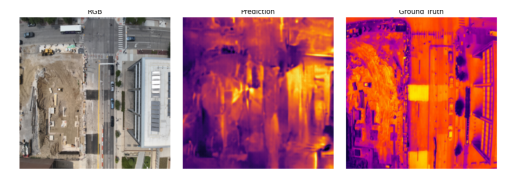

[2/6] 1.JPG | PSNR=9.6178 SSIM=0.2077 LPIPS=0.5714


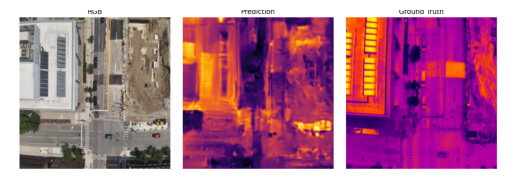

[3/6] 5.JPG | PSNR=8.0134 SSIM=0.4112 LPIPS=0.7231


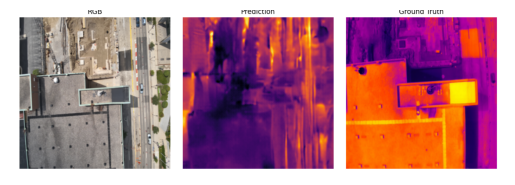

[4/6] 57.JPG | PSNR=3.5369 SSIM=0.1748 LPIPS=0.7129


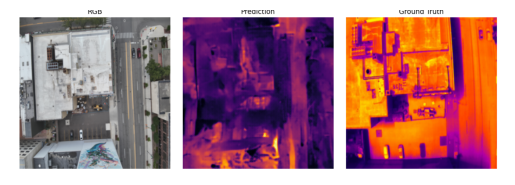

[5/6] 58.JPG | PSNR=7.6154 SSIM=0.2286 LPIPS=0.6420


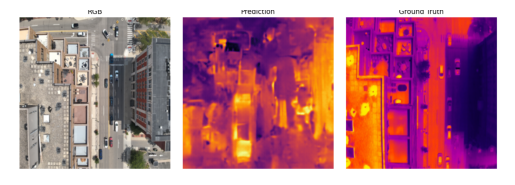

[6/6] 62.JPG | PSNR=9.5432 SSIM=0.2899 LPIPS=0.5396


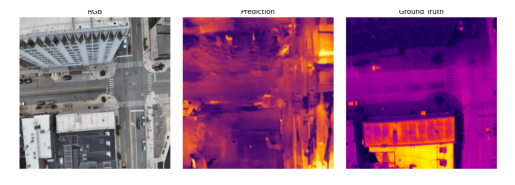

In [10]:
from utils.metrics import calculate_psnr, calculate_ssim, calculate_lpips
import matplotlib.pyplot as plt
import numpy as np


all_psnr = []
all_ssim = []
all_lpips = []

for i, (rgb_path, thermal_path) in enumerate(pairs):
    rgb_image = Image.open(rgb_path).convert("RGB")
    target_image = Image.open(thermal_path)

    rgb = eval_transform(rgb_image).unsqueeze(0).to(device)
    target = target_transform(target_image).unsqueeze(0).to(device)

    with torch.no_grad():
        dataset_idx = torch.ones(1, dtype=torch.long, device=device) * 1000
        pred_thermal = model(rgb, dataset_idx)
        pred_thermal = pred_thermal * 0.5 + 0.5
        pred_thermal = torch.clamp(pred_thermal, 0, 1)

    # ensure GT is single-channel if needed
    if target.shape[1] > 1:
        target_gray = target[:, 0:1, :, :]
    else:
        target_gray = target

    psnr = calculate_psnr(pred_thermal, target_gray, None).compute().item()
    ssim = calculate_ssim(pred_thermal, target_gray, None).compute().item()
    lpips = calculate_lpips(pred_thermal, target_gray, None).compute().item()

    all_psnr.append(psnr)
    all_ssim.append(ssim)
    all_lpips.append(lpips)

    pred_img = to_pil_image(pred_thermal[0].cpu())
    pred_img.save(out_dir / f"{rgb_path.stem}_pred.png")

    print(f"[{i+1}/{len(pairs)}] {rgb_path.name} | PSNR={psnr:.4f} SSIM={ssim:.4f} LPIPS={lpips:.4f}")
    
    # Convert tensors to displayable images
    rgb_disp = rgb_image.resize((256, 256))
    pred_disp = to_pil_image(pred_thermal[0].cpu())
    gt_disp = target_image.resize((256, 256))
    
    # Create side-by-side plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(rgb_disp)
    axes[0].set_title("RGB")
    axes[0].axis("off")
    
    axes[1].imshow(pred_disp, cmap='inferno')
    axes[1].set_title("Prediction")
    axes[1].axis("off")
    
    axes[2].imshow(gt_disp, cmap='inferno')
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")
    
    plt.tight_layout()
    
    # Save combined image
    save_path = out_dir / f"comparison/{rgb_path.stem}_comparison.png"
    plt.savefig(save_path)
    plt.close()
    
    # Optional: display inline in notebook
    plt.imshow(plt.imread(save_path))
    plt.axis("off")
    plt.show()

In [11]:
print("Mean PSNR :", sum(all_psnr) / len(all_psnr))
print("Mean SSIM :", sum(all_ssim) / len(all_ssim))
print("Mean LPIPS:", sum(all_lpips) / len(all_lpips))

Mean PSNR : 7.613621910413106
Mean SSIM : 0.25532646973927814
Mean LPIPS: 0.6359966595967611


# Metrics


*   Peak signal-to-noise ratio (PSNR)
*   Structural similarity index measure (SSIM)
*   Learned Perceptual Image Patch Similarity (LPIPS)
